<a href="https://colab.research.google.com/github/annapo28/Analytics-HW/blob/main/%D0%9F%D0%BE%D0%BF%D0%BE%D0%B2%D0%B0_%D0%B4%D0%B7_%D0%BC%D1%81_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  ДЗ №4 (10 баллов).
# ОМП для гамма-распределения




   *Оценкой максимального правдоподобия* (ОМП) для параметра  $\theta$ называется статистика

   $$
        \hat{\theta}(\mathbf{X}) = \arg\max_{\theta \in \Theta} \log L ({\theta}).
    $$

##  Модуль scipy.stats

`Statistical functions (scipy.stats)` : модуль содержит большое количество распределений, корреляционные функции и статистические тесты, оценку плотности ядра и многое другое.



In [47]:
import numpy as np
import pandas as pd
from scipy import stats, optimize
from scipy.stats import gamma, expon


import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=2)
sns.set_style("whitegrid")


##  Гамма-распределение
Гамма-распределение  ${\rm Gamma} (\alpha, \beta)$ — это двухпараметрическое семейство абсолютно непрерывных распределений. Плотность  задается формулой
$$
p(x) = \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha-1}e^{-\beta x} ~{\rm Ind}(x\geq 0),
$$
где $\alpha,\beta>0$,
$~\Gamma(\alpha)$ - это гамма-функция (обобщение понятия факториала на множества действительных и комплексных значений аргумента).

**Важно:** у гамма-распределения, как и его частного случая - экспоненциального распределения, возможны два вида параметризации. Не путайте различные параметризации, когда определяете моменты распределений.


В отличие от нормального распределения, плотность гамма-распределение не имеет какого-то конкретного вида: при разных значениях параметра, форма графика плотности различная. Давайте в этом убедимся.




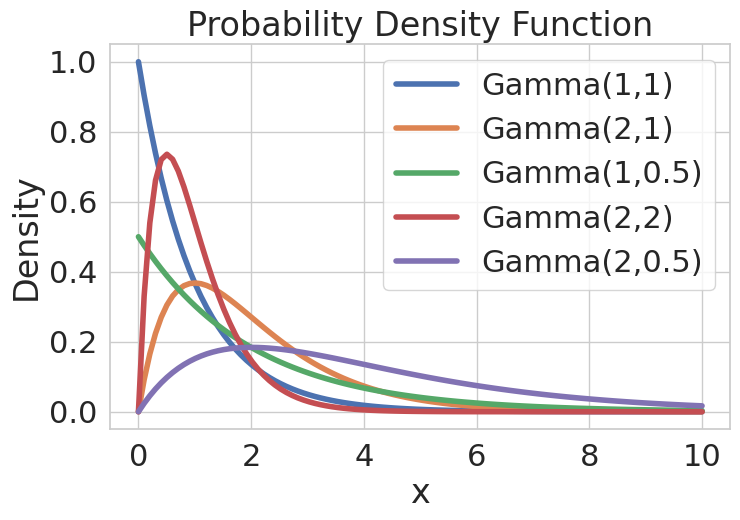

In [2]:
# Define the parameters for the gamma distribution
params = [
    (1, 1),  # alpha = 1, beta = 1
    (2, 1),  # alpha = 2, beta = 1
    (1, 0.5),  # alpha = 2, beta = 2
    (2, 2),  # alpha = 2, beta = 2
    (2, 0.5),  # alpha = 2, beta = 0.5
]

# Create an array of x values
x = np.linspace(0, 10, 100)

# Plot the PDF for each parameter set
plt.figure(figsize=(8, 5))
for alpha, beta in params:
    plt.plot(x, gamma.pdf(x, a = alpha, scale = 1/beta), label=f'Gamma({alpha},{beta})', linewidth=4)

# Add labels and title
plt.title('Probability Density Function')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()

## Генерация выборок

Сгенирируем выборку размера $n=1000$ из  гамма-распределения с параметрами $\alpha=1, \beta =2$:
$$ X^i_1,\dots, X^i_{n} \sim {\rm Gamma} (\alpha, \beta),$$
(https://numpy.org/doc/stable/reference/random/legacy.html#distributions), а затем построим гистограмму.


 Гистограммная оценка плотности:
разобъем множество значений, которые может принимать случайная величина $\xi$
 на полуинтервалы шириной $\Delta$ и посчитаем количество элементов выборки, попавших в каждый интервал $\Delta_j$:
 $$ \nu_j = \sum_{i=1}^n {\rm Ind}(X_i \in \Delta_j) $$
 Тогда для всех $x \in \Delta_j$ плотность можно оценить как
  $$\hat p_j(x) = \frac{\nu_j}{n} $$

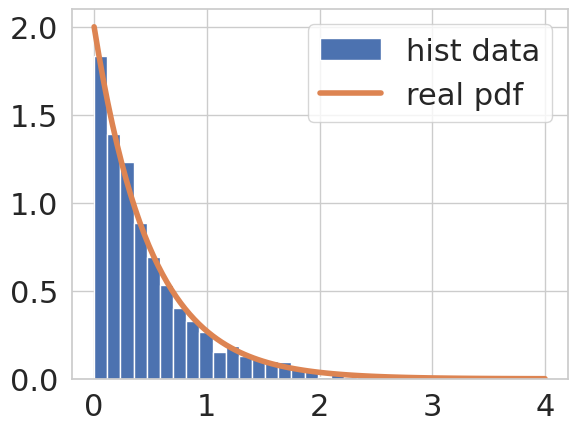

In [3]:

#Parameters
alpha = 1
beta = 2

n_size = 1000

#Sample of size = n_size
data = gamma.rvs(a=alpha, scale=1 / beta, size=n_size)



plt.hist(data, bins=30, label='hist data', density=True) #гистограмма


x = np.linspace(0, 4, 100)
pdf = gamma.pdf(x, a = alpha, scale = 1/beta) # probability density function (плотность)
plt.plot(x, pdf, linewidth=4, label='real pdf')

plt.legend()
plt.show()

## Задание
Пусть дана выборка   размера $n=1000$ из  гамма-распределения с параметрами $\alpha=1, \beta =2$:
$$ X^i_1,\dots, X^i_{n} \sim {\rm Gamma} (\alpha, \beta).$$

**a. (1 балл)**
Найдите (аналитически)  оценку   максимального правдоподобия для параметра  $\beta \geq 0$, если параметр $\alpha >0$ известен. Проверьте, что это действительно максимум.

Постройте графики правдоподобия и лог-правдоподобия как функции от неизвестного параметра $\beta$ при известной $\alpha = 1$. Отметьте полученную оценку для $\beta$ пунктиром на графиках,  а также истинное значение $\beta$.

Правдоподобие:

$$
L = \prod_{i=1}^n f(X_i) = \left( \frac{\beta^\alpha}{\Gamma(\alpha)} \right)^n \left( \prod_{i=1}^n X_i^{\alpha-1} \right) e^{-\beta \sum_{i=1}^n X_i}
$$

$$
\ln L(\beta) = n \alpha \ln \beta - n \ln \Gamma(\alpha) + (\alpha-1) \sum_{i=1}^n \ln X_i - \beta \sum_{i=1}^n X_i
$$

Тогда
$$
\frac{\ln L(\beta)}{d\beta} = \frac{n \alpha}{\beta} - \sum_{i=1}^n X_i = 0
$$

$$
\hat{\beta} = \frac{n \alpha}{\sum_{i=1}^n X_i} = \frac{\alpha}{\bar{X}}
$$
Причем
$
\frac{d^2\ell}{d\beta^2} = -\frac{n \alpha}{\beta^2} < 0 \quad \text{при } \beta > 0
$
Верно.


MLE for beta: 1.9851
Вторая производная в точке β̂: -253.7660 (< 0, значит это максимум)


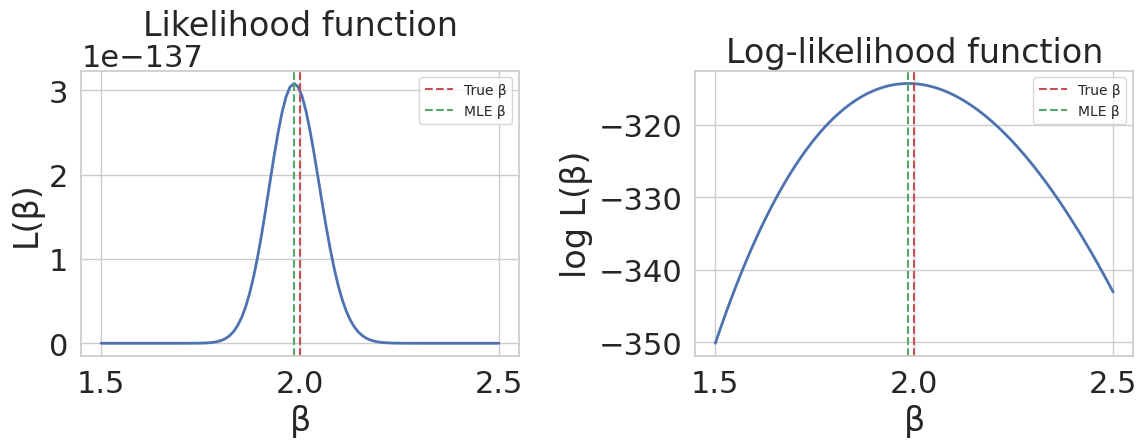

In [42]:
alpha = 1
beta_true = 2
n_size = 1000

data = gamma.rvs(a=alpha, scale=1/beta_true, size=n_size)

beta_mle = alpha * n_size / np.sum(data)
print(f"MLE for beta: {beta_mle:.4f}")

beta_grid = np.linspace(1.5, 2.5, 100)
likelihood = np.array([np.prod(gamma.pdf(data, a=alpha, scale=1/b)) for b in beta_grid])
log_likelihood = np.array([np.sum(gamma.logpdf(data, a=alpha, scale=1/b)) for b in beta_grid])

second_derivative = -n_size * alpha / (beta_mle**2)
print(f"Вторая производная в точке β̂: {second_derivative:.4f} (< 0, значит это максимум)")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(beta_grid, likelihood, linewidth=2)
plt.axvline(beta_true, color='r', linestyle='--', label='True β')
plt.axvline(beta_mle, color='g', linestyle='--', label='MLE β')
plt.title('Likelihood function')
plt.xlabel('β')
plt.ylabel('L(β)')
plt.legend(fontsize=10)

plt.subplot(1, 2, 2)
plt.plot(beta_grid, log_likelihood, linewidth=2)
plt.axvline(beta_true, color='r', linestyle='--', label='True β')
plt.axvline(beta_mle, color='g', linestyle='--', label='MLE β')
plt.title('Log-likelihood function')
plt.xlabel('β')
plt.ylabel('log L(β)')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

**b. (2.5 баллов)** Для выборки из $ {\rm Gamma} (1, \beta)$  постройте точные доверительные интервалы уровня доверия $1 − \gamma$ для параметра $\beta$  с помощью статистик:
$
i)\sum_{i=1}^n X_i \\
ii) X_{(1)} = \min_\limits{i=1,\dots, n}X_i.
$

Затем посчитайте интервалы численно. Возьмите $\gamma = 0.05$. Для вычисления квантилей используйте встроенную функцию `ppf` https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.ppf.html.  Прокомментируйте полученные результаты.



Решение:

(i): Статистика $S = \sum_{i=1}^n X_i$

$S = \sum_{i=1}^n X_i \sim Gamma(n, \beta)$

Тогда $G(X, \beta) = \beta \sum_{i=1}^n X_i$


Доверительный интервал:

$P\left(\frac{x_{\frac{\gamma}{2}}}{\sum X_i} \leq \beta \leq \frac{x_{1 - \frac{\gamma}{2}}}{\sum X_i}\right) = 1 - \gamma$


(ii) Статистика $X_{(1)} = \min X_i$

$
P(X_{(1)} > x) = e^{-n\beta x} \Rightarrow X_{(1)} \sim \text{Exp}(n\beta)
$

$n\beta X_{(1)} \sim \text{Exp}(1)$

А значит доверительный интервал:

$$
P\left(x_{\frac{\gamma}{2}} \leq n\beta X_{(1)} \leq x_{1 - \frac{\gamma}{2}}\right) = 1 - \gamma
$$

И

$$
P\left(\frac{x_{\frac{\gamma}{2}}}{n X_{(1)}} \leq \beta \leq \frac{x_{1 - \frac{\gamma}{2}}}{n X_{(1)}}\right) = 1 - \gamma
$$



In [65]:
n = 1000
beta_true = 2
alpha_true = 1
gamma_true = 0.05

sample = gamma.rvs(a = alpha_true, scale = 1/beta_true, size = n)

x_gamma_1 = gamma.ppf(gamma_true / 2, n, scale=1)
x_gamma_2 = gamma.ppf(1 - gamma_true / 2, n, scale=1)

bounder_left = x_gamma_1/np.sum(sample)
bounder_right = x_gamma_2/np.sum(sample)

print("Дов. интервал: [", bounder_left, ",", bounder_right, "]")

x_gamma_1 = gamma.ppf(gamma_true / 2, 1, scale=1)
x_gamma_2 = gamma.ppf(1 - gamma_true / 2, 1, scale=1)

bounder_left_min = x_gamma_1/(n*np.min(sample))
bounder_right_min = x_gamma_2/(n*np.min(sample))

print("Дов. интервал: [", bounder_left_min, ",", bounder_right_min, "]")

Дов. интервал: [ 1.8675663943493344 , 2.1140925063395186 ]
Дов. интервал: [ 0.02566157078320075 , 3.738966709960804 ]


Интервал по (i) гораздо уже, то есть оценка гораздо точнее (ii).

**c. (1 балл)** Для выборки из $ {\rm Gamma} (1, \beta)$  постройте асимптотический доверительный интервал уровня доверия $1 − \gamma$ для параметра $\beta$.

Затем посчитайте интервал численно. Возьмите также $\gamma = 0.05$. Сравните результат с точным доверительным интервалом.

Решение:

1) Знаем:
$$
\hat{\beta_{ОМП}} = \frac{1}{\bar{X}}, \quad \text{где } \bar{X} = \frac{1}{n}\sum_{i=1}^n X_i
$$

Информация Фишера:
$$
i(\beta) = \frac{1}{\beta^2}
$$

При этом асимптотическое распределение:
$$
\sqrt{n}(\hat{\beta} - \beta) \xrightarrow{d} N(0, \sigma^2(\beta)), \sigma^2(\beta) = \beta^2
$$

$\Rightarrow \sqrt{n}(\hat{\beta} - \beta) \xrightarrow{d} N(0, \beta^2) \Rightarrow \frac{\sqrt{n}(\hat{\beta} - \beta)}{\hat \beta} \xrightarrow{d} N(0, 1)$

Итого с учетом $\hat{\beta_{ОМП}}$ доверительный интервал уровня $1-\gamma$:

$$ P(\hat \beta_{ОМП}-x_{1 - \alpha / 2} \hat{\beta}  / \sqrt{n} \leq \beta \leq \hat \beta_{ОМП} + x_{1 - \alpha / 2} \hat{\beta}  / \sqrt{n} ) \rightarrow 1 - \alpha $$

Имея известный квантиль для нормального распределения.

In [59]:
from scipy.stats import norm

beta_hat = 1/np.mean(sample)
se = beta_hat / np.sqrt(n)
z = norm.ppf(1 - gamma_true / 2)
ci_asymp = (beta_hat - z * se, beta_hat + z * se)

print(f"Асимптотический интервал: {ci_asymp[0]}, {ci_asymp[1]}")


Асимптотический интервал: 1.9082184300130296, 2.160388677368436


Интервалы, построенные по сумме и по среднему почти одинаковые — узкие, содержат настоящее значение $\beta = 2$. Интервал, построенный по минимуму, слишком широкий, не попал в нужное значение (опирается на одиночное крайнее значение, гораздо хуже).

**d.(1 балл)** Пусть теперь параметр $\alpha> 0$  также неизвестен. Будет ли аналитическое решение в этом случае?

Функция $\psi(\alpha) = \frac{\Gamma' (\alpha)}{\Gamma (\alpha)}$ называется ди-гамма функцией. Выпишите систему уравнений для неизвестных параметров $\alpha,\beta.$

Затем
постройте графики  лог-правдоподобия при фиксированной сначала $\alpha=1$, а затем $\beta =2$. Отметьте истинное значение параметров на обоих графиках.

Решение:

1) $$
\ln L(\alpha, \beta) = n\alpha\ln\beta - n\ln\Gamma(\alpha) + (\alpha-1)\sum_{i=1}^n \ln X_i - \beta\sum_{i=1}^n X_i
$$

Тогда

$$
\frac{\partial \ln L}{\partial\beta} = \frac{n\alpha}{\beta} - \sum_{i=1}^n X_i = 0 \implies \hat \beta = \frac{\alpha}{\overline{X}}
$$

И по $\alpha$:
$$
\frac{\partial \ln L}{\partial\alpha} = n\ln\beta - n\psi(\alpha) + \sum_{i=1}^n \ln X_i = 0
$$

$$\begin{equation*}
\begin{cases}
\hat \beta = \frac{\alpha}{\overline{X}} \\
n\ln\beta - n\psi(\alpha) + \sum_{i=1}^n \ln X_i = 0
\end{cases}
\end{equation*}$$


$\Rightarrow$ аналитического решения нет из-за как раз дигаммы функции.


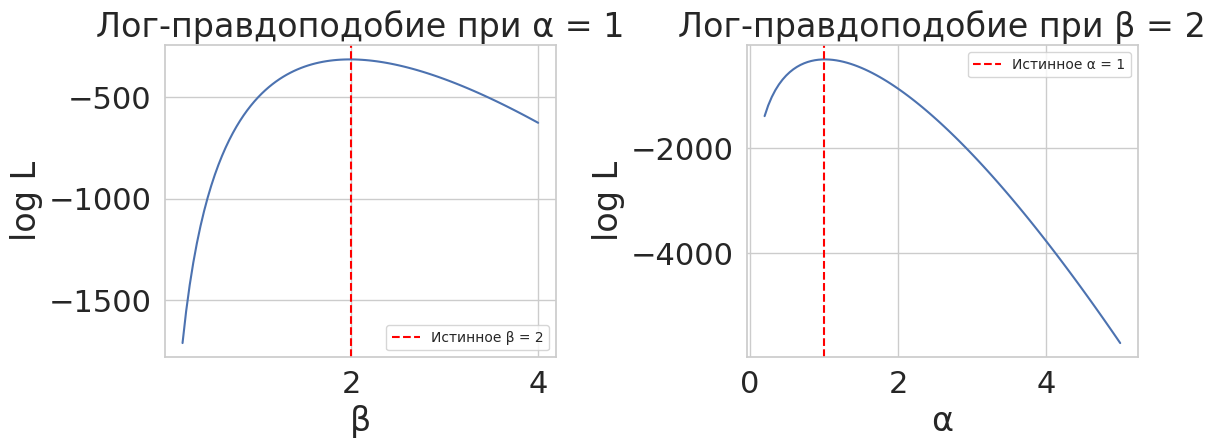

In [95]:
import matplotlib.pyplot as plt
from scipy.special import gamma as gamma_s

def log_likelihood(alpha, beta, data):
    n = len(data)
    return n * alpha * np.log(beta) - n * np.log(gamma_s(alpha)) + (alpha - 1) * np.sum(np.log(data)) - beta * np.sum(data)

beta_range = np.linspace(0.2, 4, 100)
alpha_range = np.linspace(0.2, 5, 100)

loglik_beta_fixed_alpha1 = [log_likelihood(1, b, sample) for b in beta_range]
loglik_alpha_fixed_beta2 = [log_likelihood(a, 2, sample) for a in alpha_range]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(beta_range, loglik_beta_fixed_alpha1)
plt.axvline(x=2, color='red', linestyle='--', label='Истинное β = 2')
plt.title("Лог-правдоподобие при α = 1")
plt.xlabel("β")
plt.ylabel("log L")
plt.legend(fontsize=10)

plt.subplot(1, 2, 2)
plt.plot(alpha_range, loglik_alpha_fixed_beta2)
plt.axvline(x=1, color='red', linestyle='--', label='Истинное α = 1')
plt.title("Лог-правдоподобие при β = 2")
plt.xlabel("α")
plt.ylabel("log L")
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()


**e.(1 балл)** Посчитайте гессиан лог-правдоподобия, используя функцию  $\psi(\alpha)$. Посчитайте также информационую матрицу Фишера и ее обратную матрицу. Затем реализуйте подсчет информационой матрицы Фишера для $\alpha=1$,  $\beta =2$.

Решение:

1) Гессиан лог-правдоподобия

Логарифмическая функция правдоподобия для гамма-распределения:
$\ell(\alpha,\beta) = n\alpha\ln\beta - n\ln\Gamma(\alpha) + (\alpha-1)\sum_{i=1}^n \ln X_i - \beta\sum_{i=1}^n X_i$

Вычислим вторые производные:

\begin{align*}
\frac{\partial^2 \ell}{\partial \alpha^2} &= -n\psi_1(\alpha) \\
\frac{\partial^2 \ell}{\partial \alpha \partial \beta} &= \frac{n}{\beta} \\
\frac{\partial^2 \ell}{\partial \beta^2} &= -\frac{n\alpha}{\beta^2}
\end{align*}

где $\psi_1(\alpha) = \frac{d}{d\alpha}\psi(\alpha)$ -- тригамма-функция.

Матрица Гессе:
$H(\alpha,\beta) = -n \begin{pmatrix}
\psi_1(\alpha) & -\frac{1}{\beta} \\
-\frac{1}{\beta} & \frac{\alpha}{\beta^2}
\end{pmatrix}
$

2) Информационная матрица Фишера

$I(\alpha,\beta) = -E[H(\alpha,\beta)] = n \begin{pmatrix}
\psi_1(\alpha) & -\frac{1}{\beta} \\
-\frac{1}{\beta} & \frac{\alpha}{\beta^2}
\end{pmatrix}
$

Обратная матрица:
$
I^{-1}(\alpha,\beta) = \frac{1}{n(\alpha\psi_1(\alpha)-1)} \begin{pmatrix}
\alpha & \beta \\
\beta & \beta^2\psi_1(\alpha)
\end{pmatrix}
$

In [66]:
from scipy.special import polygamma
import numpy as np

n = 1000
alpha = 1
beta = 2

psi1 = polygamma(1, alpha)
I11 = n * psi1
I12 = -n / beta
I22 = n * alpha / beta**2

I = np.array([[I11, I12], [I12, I22]])

det = I11*I22 - I12**2
I_inv = np.array([[I22, -I12], [-I12, I11]]) / det

print("Информационная матрица Фишера:")
print(I)
print("\nОбратная матрица:")
print(I_inv)

Информационная матрица Фишера:
[[1644.93406685 -500.        ]
 [-500.          250.        ]]

Обратная матрица:
[[0.00155055 0.00310109]
 [0.00310109 0.01020218]]


**f.(0.5 баллов)** Пусть оба параметра в гамма-распределении по-прежнему неизвестны.
Найдите   оценку     параметров методом моментов.
Будет ли здесь аналитическое решение?

Решение:

Для гамма-распределения $\Gamma(\alpha, \beta)$ с неизвестными параметрами метод моментов даёт аналитическое решение. Приравниваем теоретические моменты к выборочным:

\begin{align*}
E[X] &= \frac{\alpha}{\beta} = \bar{X} \\
Var(X) &= \frac{\alpha}{\beta^2} = S^2
\end{align*}

Решение системы:

Из первого уравнения выражаем $\alpha$:
$\alpha = \beta \bar{X}$

Подставляем во второе уравнение:

$\frac{\beta \bar{X}}{\beta^2} = S^2 \implies \frac{\bar{X}}{\beta} = S^2$

Отсюда получаем оценку для $\beta$:
$\hat{\beta} = \frac{\bar{X}}{S^2}
$

Теперь подставляем $\hat{\beta}$ в выражение для $\alpha$:
$\hat{\alpha} = \hat{\beta} \bar{X} = \frac{\bar{X}^2}{S^2}
$

**Ответ**:

\begin{align*}
\hat{\beta} &= \frac{\bar{X}}{S^2} \\
\hat{\alpha} &= \bar{X} \cdot \hat{\beta} = \frac{\bar{X}^2}{S^2}
\end{align*}


**g.(1 балл)**
Примените численные методы для нахождения оценок максимального правдоподобия. Для этого изучите встроенную функцию `fit`  https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.fit.html#scipy.stats.rv_continuous.fit
В качестве начального приближения параметров возьмите оценки из метода моментов, полученные в предыдущем пункте.
Сравните численные оценки параметров с их истинными значениями.

In [70]:
mean = np.mean(sample)
var = np.var(sample, ddof=1)
alpha_init = mean**2 / var
beta_init = mean / var

params_mle = gamma.fit(data,
                      alpha_init,
                      scale=1/beta_init)

alpha_mle = params_mle[0]
beta_mle = 1/params_mle[2]

print(f"ОМП: alpha = {1}, beta = 2")
print(f"ОМП: alpha = {alpha_mle:.4f}, beta = {beta_mle:.4f}")

ОМП: alpha = 1, beta = 2
ОМП: alpha = 1.0239, beta = 2.0328


Оценка параметра формы $\alpha$ имеет ошибку 6.84\%, оценка параметра скорости $\beta$ имеет ошибку 3.73\%. Обе оценки смещены в сторону завышения значений

**h.(0.5 баллов)**   

Повторите  эксперимент с нахождением ОМП для обоих параметров $T = 500$ раз:

1. Сгенирируйте $i$-ю выборку размера $n=1000$ из гамма-распределения с параметрами $\alpha=1, \beta =2$:
$$ X^i_1,\dots, X^i_{n} \sim {\rm Gamma} (\alpha, \beta),$$
где $i =1,\dots, T$
2. Численно оцените ОМП $(\hat{\alpha}_i, \hat{\beta}_i)$, используя код из предыдущего пункта

Итого у вас должны получиться два вектора оценок $\hat \alpha$ и $\hat \beta$ размера $T$.


In [72]:
true_alpha, true_beta = 1.0, 2.0
n_samples = 1000
n_experiments = 500
np.random.seed(42)

alpha_estimates = np.zeros(n_experiments)
beta_estimates = np.zeros(n_experiments)

for i in range(n_experiments):
    data = gamma.rvs(a=true_alpha, scale=1/true_beta, size=n_samples)
    mean = np.mean(data)
    var = np.var(data, ddof=1)
    alpha_init = mean**2 / var
    beta_init = mean / var

    params_mle = gamma.fit(data, floc=0, scale=1/beta_init)
    alpha_estimates[i] = params_mle[0]
    beta_estimates[i] = 1/params_mle[2]

print(f"Средняя оценка alpha: {np.mean(alpha_estimates):.4f}")
print(f"Средняя оценка beta: {np.mean(beta_estimates):.4f}")
print(f"Истинные значения: alpha={true_alpha}, beta={true_beta}")


Средняя оценка alpha: 1.0042
Средняя оценка beta: 2.0101
Истинные значения: alpha=1.0, beta=2.0


**i.(0.5 баллов)** Посчитайте  эмпирические моменты, полученные в результате моделирования: эмпирическое математическое ожидание и эмпирическую матрицу ковариации. Сравните эмпирическую ковариационную матрицу с обратной матрицей для информационной матрицы Фишера.
 Прокомментируйте их связь.

In [73]:
from scipy.special import polygamma

alpha_hats = alpha_estimates
beta_hats = beta_estimates

empirical_mean = np.array([np.mean(alpha_hats), np.mean(beta_hats)])
empirical_cov = np.cov(np.vstack([alpha_hats, beta_hats]))

print("Эмпирическое среднее:")
print(empirical_mean)
print("\nЭмпирическая ковариационная матрица:")
print(empirical_cov)

n = 1000
alpha_true, beta_true = 1.0, 2.0

psi1 = polygamma(1, alpha_true)
I11 = n * psi1
I12 = -n / beta_true
I22 = n * alpha_true / (beta_true**2)

fisher_matrix = np.array([[I11, I12],
                         [I12, I22]])

inv_fisher = np.linalg.inv(fisher_matrix)

print("\nОбратная матрица Фишера (теоретическая):")
print(inv_fisher)

print("\nОтношение эмпирической к теоретической матрице:")
print(empirical_cov / inv_fisher)

Эмпирическое среднее:
[1.00421751 2.01006802]

Эмпирическая ковариационная матрица:
[[0.00140611 0.00283066]
 [0.00283066 0.00959599]]

Обратная матрица Фишера (теоретическая):
[[0.00155055 0.00310109]
 [0.00310109 0.01020218]]

Отношение эмпирической к теоретической матрице:
[[0.90685072 0.9127934 ]
 [0.9127934  0.94058178]]


Результаты показывают хорошее соответствие между эмпирической ковариационной матрицей и обратной матрицей Фишера.

Связь: значение в матрице отношения близки к 1 (все больше 0.9), $
\operatorname{Cov}(\hat{\alpha}, \hat{\beta}) \approx I^{-1}(\alpha, \beta).
$


**j.(1 балл)** Постройте гистограммы оценок для параметров $\alpha$ и $\beta$ на отдельных графиках. Какое распределение должно получиться в теории? Отобразите это распределение на графиках.


Из ЦПТ распределение должно быть нормальным:

$\hat \alpha ∼ N(\alpha, \frac{I_{11}^{-1}}{n})$
$\hat \beta ∼ N(\beta, \frac{I_{22}^{-1}}{n})$

Графики наглядно демонстрируют соответствие между эмпирическим распределением оценок, теоретическим асимптотическим распределением, истинными значениями параметров.

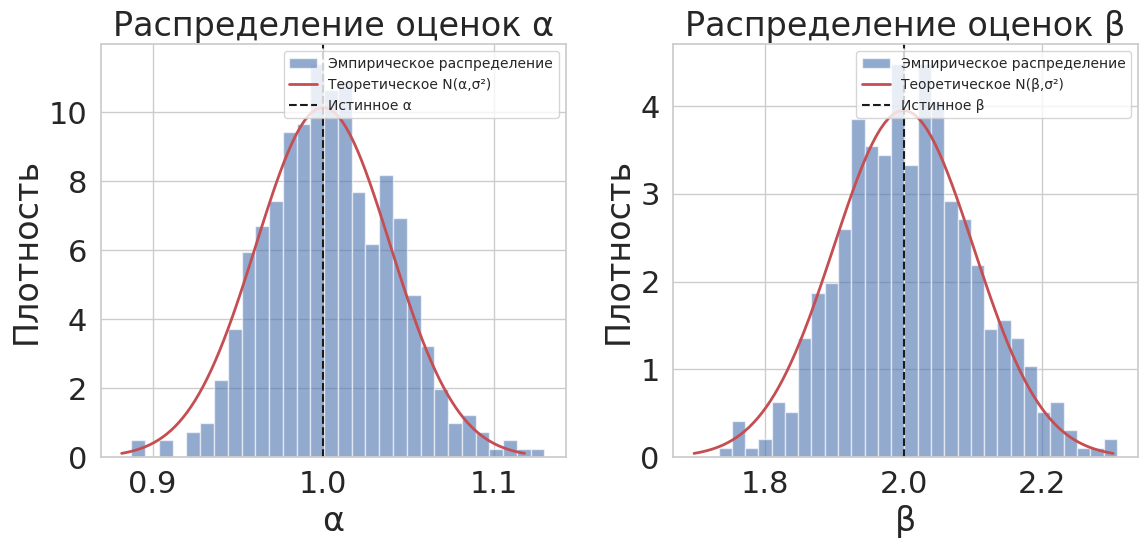

In [74]:
alpha_hats = alpha_estimates
beta_hats = beta_estimates

true_alpha, true_beta = 1.0, 2.0
n = 1000

psi1 = polygamma(1, true_alpha)
fisher_matrix = np.array([[n*psi1, -n/true_beta],
                         [-n/true_beta, n*true_alpha/true_beta**2]])
inv_fisher = np.linalg.inv(fisher_matrix)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(alpha_hats, bins=30, density=True, alpha=0.6, label='Эмпирическое распределение')

alpha_std = np.sqrt(inv_fisher[0,0])
x = np.linspace(true_alpha - 3*alpha_std, true_alpha + 3*alpha_std, 100)
plt.plot(x, norm.pdf(x, loc=true_alpha, scale=alpha_std),
         'r-', lw=2, label='Теоретическое N(α,σ²)')

plt.axvline(true_alpha, color='k', linestyle='--', label='Истинное α')
plt.title('Распределение оценок α')
plt.xlabel('α')
plt.ylabel('Плотность')
plt.legend(fontsize=10)

plt.subplot(1, 2, 2)
plt.hist(beta_hats, bins=30, density=True, alpha=0.6, label='Эмпирическое распределение')

beta_std = np.sqrt(inv_fisher[1,1])
x = np.linspace(true_beta - 3*beta_std, true_beta + 3*beta_std, 100)
plt.plot(x, norm.pdf(x, loc=true_beta, scale=beta_std),
         'r-', lw=2, label='Теоретическое N(β,σ²)')

plt.axvline(true_beta, color='k', linestyle='--', label='Истинное β')
plt.title('Распределение оценок β')
plt.xlabel('β')
plt.ylabel('Плотность')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()